# Análisis de umbral

### Importación de librerías.

In [31]:
import __main__
from modelo_c import ModeloEnsambladoFraude
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay
import joblib
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.base import BaseEstimator, TransformerMixin
import ast

### Importación de datos.

In [32]:
df = pd.read_csv('datos_sinteticos.csv', sep=";")
df.head(2)

,cliente_id,fechas_hora,montos,tipos_establecimiento,historico_establecimiento,es_anomalia,tipo_anomalia,promedio,desviacion,maximo,minimo,monto_hora,moda_establecimiento,cantidad_establecimiento
0,1,"['2026-06-08 00:16:00', '2026-06-08 06:14:00',...","['705.29', '628.12', '272.24', '382.26', '1109...","['Farmacia', 'Farmacia', 'Transporte', 'Farmac...","['0.16643057183060853', '0.017594963536259', '...",0,Normal,879.374333,602.582962,2380.04,240.25,34.208766,Farmacia,7
1,2,"['2026-06-14 07:11:00', '2026-06-15 07:48:00',...","['266.04', '518.87', '266.71', '193.6', '264.7...","['Otros', 'Otros', 'Transporte', 'Transporte',...","['0.001894439046728334', '0.01438288653067728'...",0,Normal,346.078000,165.763599,762.78,63.60,16.192467,Otros,5


### Separando las variables predictoras de la objetivo.

In [33]:
X = df.drop(columns = ['es_anomalia'])
y = df['es_anomalia']

### Separación del conjunto de prueba y entrenamiento.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=X['tipo_anomalia'])

### Costos.

In [35]:
COSTO_FN = 4200
COSTO_FP = 180

## Modelo A

### Data frame útil para el modelo.

In [36]:
X_train_a =  X_train.drop(columns=['cliente_id', 'fechas_hora', 'montos', 'tipos_establecimiento', 'historico_establecimiento'])
X_test_a =  X_test.drop(columns=['cliente_id', 'fechas_hora', 'montos', 'tipos_establecimiento', 'historico_establecimiento'])

### Importación del modelo.

In [37]:
modelo_A = joblib.load("modelo_A.pkl")

### Predicción de la probabilidad.

In [38]:
y_prob_a = modelo_A.predict_proba(X_train_a)[:, 1]

### Métricas respecto a umbrales.

In [39]:
fpr_a, tpr_a, thresholds_a = roc_curve(y_true=y_train, y_score=y_prob_a, drop_intermediate=False)
positivos_a = np.sum(y_train == 1)
negativos_a = np.sum(y_train == 0)

In [40]:
resultados_a = pd.DataFrame({"umbral": thresholds_a, "TP": np.rint(tpr_a * positivos_a).astype(int),
                           "FP": np.rint(fpr_a * negativos_a).astype(int)})

resultados_a["FN"] = positivos_a - resultados_a["TP"]
resultados_a["TN"] = negativos_a - resultados_a["FP"]
resultados_a["costo_total"] = (resultados_a["FN"] * COSTO_FN + resultados_a["FP"] * COSTO_FP)
resultados_a.head()

,umbral,TP,FP,FN,TN,costo_total
0,inf,0,0,8051,71949,33814200
1,0.978197,1,0,8050,71949,33810000
2,0.978002,2,0,8049,71949,33805800
3,0.975796,3,0,8048,71949,33801600
4,0.973375,4,0,8047,71949,33797400


### Mejor umbral.

In [41]:
mejor_fila_a = resultados_a.loc[resultados_a["costo_total"].idxmin()]
umbral_optimo_a = mejor_fila_a["umbral"]

print(f"Umbral óptimo: {umbral_optimo_a:.4f}")
print(f"Falsos negativos: {int(mejor_fila_a['FN'])}")
print(f"Falsos positivos: {int(mejor_fila_a['FP'])}")
print(f"Costo mínimo: Q{mejor_fila_a['costo_total']/len(y_train):,.2f}")

Umbral óptimo: 0.4440
Falsos negativos: 4
Falsos positivos: 1724
Costo mínimo: Q4.09


### Gráfico del umbral óptimo.

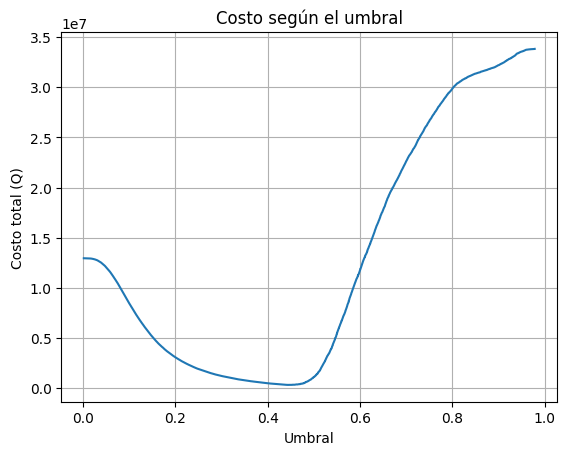

In [42]:
plt.plot(resultados_a["umbral"], resultados_a["costo_total"])
plt.xlabel("Umbral")
plt.ylabel("Costo total (Q)")
plt.title("Costo según el umbral")
plt.grid()
plt.show()

### Matriz de confusión (Conjunto de entrenamiento).

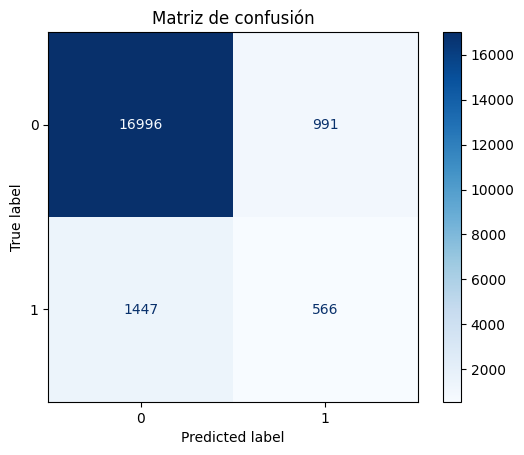

In [43]:
y_prob_test_a = modelo_A.predict_proba(X_test_a)[:, 1]
y_pred_optimo_a = (y_prob_test_a >= umbral_optimo_a).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimo_a, cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

## Modelo B.

### Data frame útil para el modelo.

In [44]:
X_train_b =  X_train[['montos']]
X_test_b =  X_test[['montos']]

### Funciones del pipeline.

In [45]:
def convertir_montos(datos):

    # Se genera una serie.
    if isinstance(datos, pd.DataFrame):
        columna = datos.iloc[:, 0]
    else:
        columna = datos

    # Se separan los datos para convertirlos en listas de números.
    montos_separados = (columna.astype("string").str.strip().str.slice(1, -1).str.replace("'", "", regex=False).str.split(r",\s*", expand=True, regex=True))

    return montos_separados.to_numpy(dtype=np.float32)

class EscaladorGlobalSecuencias(BaseEstimator, TransformerMixin):

    # Entrenador del modelo.
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=np.float32)

        self.media_ = X.mean()
        self.desviacion_ = X.std(ddof=0)

        if self.desviacion_ == 0:
            self.desviacion_ = 1.0

        return self

    # Transformador del modelo.
    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return ((X - self.media_) / self.desviacion_).astype(np.float32)

### Importación de modelo

In [46]:
pipeline_b = joblib.load("pipeline_b.joblib")
modelo_B = load_model("modelo_b.keras")

### Aplicando preprocesamiento.

In [47]:
X_train_b = pipeline_b.transform(X_train_b)
X_test_b = pipeline_b.transform(X_test_b)

### Predicción de la probabilidad.

In [48]:
y_prob_b = modelo_B.predict(X_train_b)

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step


### Métricas respecto a umbrales.

In [49]:
fpr_b, tpr_b, thresholds_b = roc_curve(y_true=y_train, y_score=y_prob_b, drop_intermediate=False)
positivos_b = np.sum(y_train == 1)
negativos_b = np.sum(y_train == 0)

In [50]:
resultados_b = pd.DataFrame({"umbral": thresholds_b, "TP": np.rint(tpr_b * positivos_b).astype(int),
                           "FP": np.rint(fpr_b * negativos_b).astype(int)})

resultados_b["FN"] = positivos_b - resultados_b["TP"]
resultados_b["TN"] = negativos_b - resultados_b["FP"]
resultados_b["costo_total"] = (resultados_b["FN"] * COSTO_FN + resultados_b["FP"] * COSTO_FP)
resultados_b.head()

,umbral,TP,FP,FN,TN,costo_total
0,inf,0,0,8051,71949,33814200
1,0.999484,1,0,8050,71949,33810000
2,0.999404,2,0,8049,71949,33805800
3,0.999101,3,0,8048,71949,33801600
4,0.998975,4,0,8047,71949,33797400


### Mejor umbral.

In [51]:
mejor_fila_b = resultados_b.loc[resultados_b["costo_total"].idxmin()]
umbral_optimo_b = mejor_fila_b["umbral"]

print(f"Umbral óptimo: {umbral_optimo_b:.4f}")
print(f"Falsos negativos: {int(mejor_fila_b['FN'])}")
print(f"Falsos positivos: {int(mejor_fila_b['FP'])}")
print(f"Costo mínimo: Q{mejor_fila_b['costo_total']/len(y_train):,.2f}")

Umbral óptimo: 0.2937
Falsos negativos: 19
Falsos positivos: 71413
Costo mínimo: Q161.68


### Gráfico del umbral óptimo.

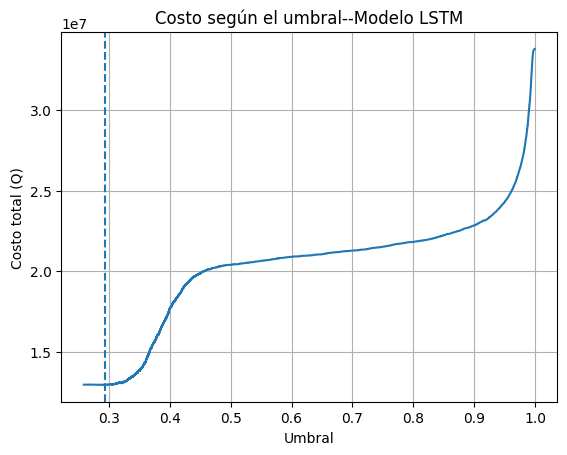

In [52]:
plt.plot(resultados_b["umbral"], resultados_b["costo_total"])
plt.axvline(umbral_optimo_b, linestyle="--",label=f"Óptimo = {umbral_optimo_b:.2f}")
plt.xlabel("Umbral")
plt.ylabel("Costo total (Q)")
plt.title("Costo según el umbral--Modelo LSTM")
plt.grid()
plt.show()

### Matriz de confusión.

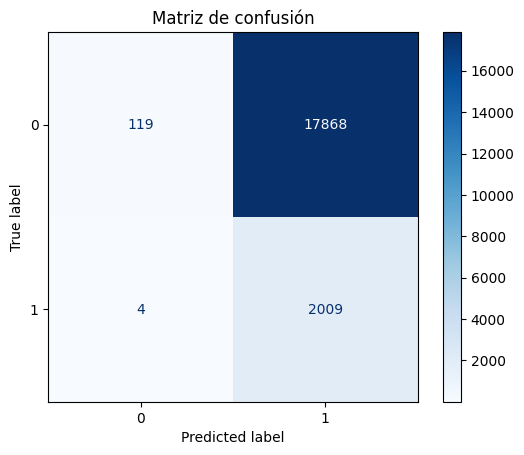

In [53]:
y_prob_test_b = modelo_B.predict(X_test_b, batch_size=32, verbose=0).ravel()
y_pred_optimo_b = (y_prob_test_b >= umbral_optimo_b).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimo_b, cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

## Modelo C.

### DataFrame útil para el modelo.

In [54]:
X_train_c =  X_train[['fechas_hora', 'montos', 'tipos_establecimiento', 'historico_establecimiento']]
X_test_c =  X_test[['fechas_hora', 'montos', 'tipos_establecimiento', 'historico_establecimiento']]

### Importación del modelo.

In [55]:
modelo_C = ModeloEnsambladoFraude(umbral=0.50, batch_size=256)

### Predicción de la probabilidad.

In [56]:
y_prob_c = modelo_C.predict(X_train_c)['probabilidad_mayor']

### Métricas respecto a umbrales.

In [57]:
fpr_c, tpr_c, thresholds_c = roc_curve(y_true=y_train, y_score=y_prob_c, drop_intermediate=False)
positivos_c = np.sum(y_train == 1)
negativos_c = np.sum(y_train == 0)

In [58]:
resultados_c = pd.DataFrame({"umbral": thresholds_c, "TP": np.rint(tpr_c * positivos_c).astype(int),
                           "FP": np.rint(fpr_c * negativos_c).astype(int)})

resultados_c["FN"] = positivos_c - resultados_c["TP"]
resultados_c["TN"] = negativos_c - resultados_c["FP"]
resultados_c["costo_total"] = (resultados_c["FN"] * COSTO_FN + resultados_c["FP"] * COSTO_FP)
resultados_c.head()

,umbral,TP,FP,FN,TN,costo_total
0,inf,0,0,8051,71949,33814200
1,1.0,1,0,8050,71949,33810000
2,1.0,2,0,8049,71949,33805800
3,1.0,3,0,8048,71949,33801600
4,1.0,4,0,8047,71949,33797400


### Mejor umbral.

In [59]:
mejor_fila_c = resultados_c.loc[resultados_c["costo_total"].idxmin()]
umbral_optimo_c = mejor_fila_c["umbral"]

print(f"Umbral óptimo: {umbral_optimo_c:.4f}")
print(f"Falsos negativos: {int(mejor_fila_c['FN'])}")
print(f"Falsos positivos: {int(mejor_fila_c['FP'])}")
print(f"Costo mínimo: Q{mejor_fila_c['costo_total']/len(y_train):,.2f}")

Umbral óptimo: 0.4789
Falsos negativos: 78
Falsos positivos: 4346
Costo mínimo: Q13.87


### Gráfico del umbral óptimo.

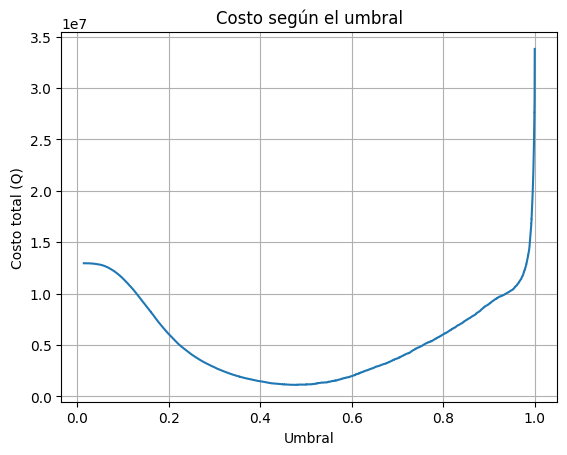

In [60]:
plt.plot(resultados_c["umbral"], resultados_c["costo_total"])
plt.xlabel("Umbral")
plt.ylabel("Costo total (Q)")
plt.title("Costo según el umbral")
plt.grid()
plt.show()

### Matriz de confusión (Conjunto de entrenamiento).

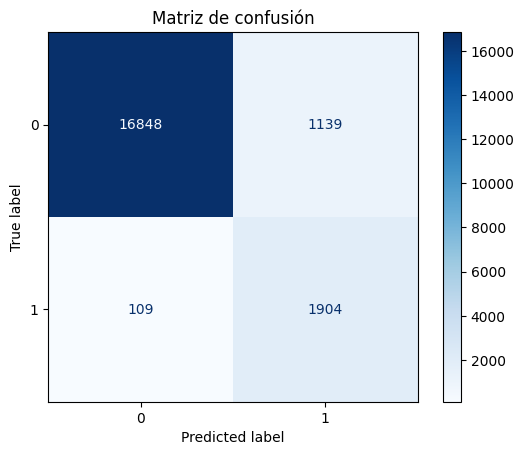

In [61]:
y_prob_test_c = modelo_C.predict(X_test_c)['probabilidad_mayor']
y_pred_optimo_c = (y_prob_test_c >= umbral_optimo_c).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimo_c, cmap="Blues")
plt.title("Matriz de confusión")
plt.show()